<a href="https://colab.research.google.com/github/progirlly18/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```



# Credit Card Fraud Detection using Machine Learning

## Project Overview

This project develops a machine learning system for detecting fraudulent credit card transactions.

The dataset contains highly imbalanced transaction classes, making fraud detection challenging. Multiple machine learning approaches are evaluated, including Logistic Regression, Random Forest, and XGBoost.

The project focuses on precision, recall, F1-score, ROC-AUC, and PR-AUC, with particular emphasis on precision-recall performance under severe class imbalance.


#1.Import Libraries

In [79]:
# Credit Card Fraud Detection
# Phase 1 - Data Loading and Exploration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

In [78]:
!unzip archive.zip

Archive:  archive.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [3]:
!ls

archive.zip  creditcard.csv  sample_data


#2. Load Dataset

In [4]:
import pandas as pd

df = pd.read_csv('/content/creditcard.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

The dataset contains 284,807 transactions and 31 columns, including the target variable `Class`.

- `Class = 0`: Legitimate transaction
- `Class = 1`: Fraudulent transaction

#3.Exploratory Data Analysis

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


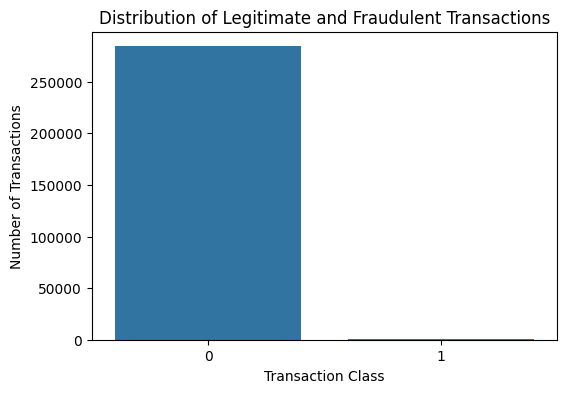

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Class')

plt.title('Distribution of Legitimate and Fraudulent Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')

plt.show()

In [12]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


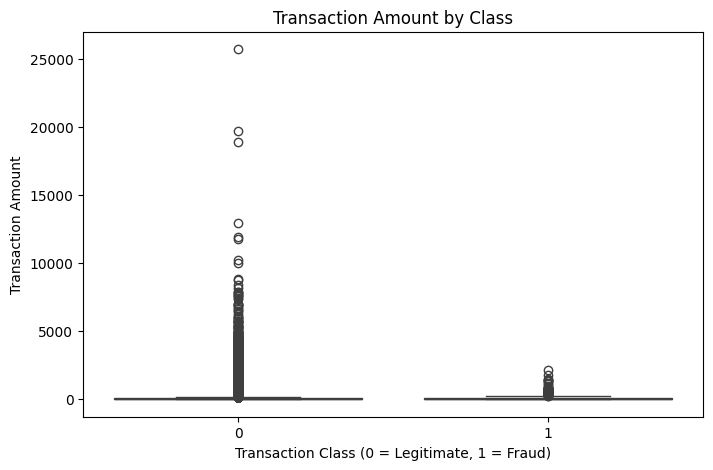

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Class', y='Amount')

plt.title('Transaction Amount by Class')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Amount')

plt.show()

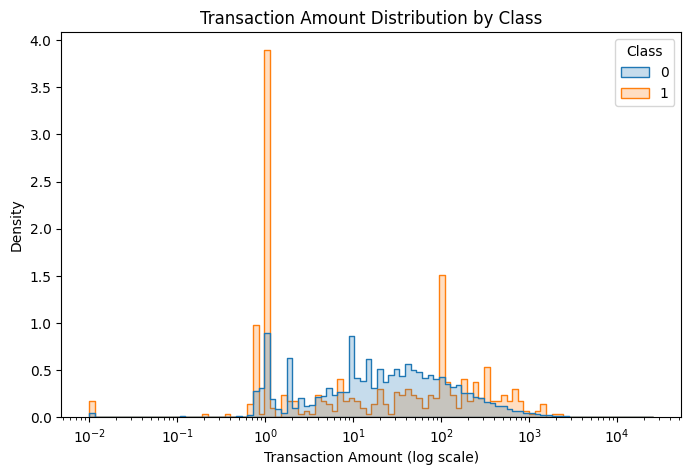

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=100,
    log_scale=True,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Transaction Amount Distribution by Class')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Density')

plt.show()

In [15]:
df['Time'].describe()

,Time
count,284807.000000
mean,94813.859575
std,47488.145955
min,0.000000
25%,54201.500000
50%,84692.000000
75%,139320.500000
max,172792.000000


In [16]:
print("Minimum Time:", df['Time'].min())
print("Maximum Time:", df['Time'].max())

Minimum Time: 0.0
Maximum Time: 172792.0


##4. Feature Engineering

The original `Time` feature represents elapsed seconds. An additional `Hour` feature was derived by converting elapsed seconds into hours to investigate whether transaction timing provides useful information for fraud detection.

In [17]:
df['Hour'] = (df['Time'] / 3600) % 24

df[['Time', 'Hour', 'Class']].head(10)

,Time,Hour,Class
0,0.0,0.000000,0
1,0.0,0.000000,0
2,1.0,0.000278,0
3,1.0,0.000278,0
4,2.0,0.000556,0
5,2.0,0.000556,0
6,4.0,0.001111,0
7,7.0,0.001944,0
8,7.0,0.001944,0
9,9.0,0.002500,0


In [18]:
df.groupby('Class')['Hour'].mean()

,Hour
Class,
0,14.542106
1,12.136986


In [19]:
df.groupby('Class')['Hour'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,14.542106,5.844597,0.000000,10.601389,15.014167,19.332778,23.999444
1,492.0,12.136986,6.719614,0.112778,5.923819,12.052361,17.803681,23.993333


In [20]:
correlations = df.corr(numeric_only=True)['Class'].sort_values()

print(correlations)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Hour     -0.017082
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


#6. Train-Test-Validation Split

### Data Splitting Strategy

The dataset was first divided into training and testing sets using stratified sampling to preserve the minority-class proportion.

The training set was subsequently divided into an inner training set and validation set for threshold selection.

The final test set remained untouched until final evaluation.

In [21]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (227845, 31)
Testing set: (56962, 31)


In [22]:
print("Training fraud percentage:", y_train.mean() * 100)
print("Testing fraud percentage:", y_test.mean() * 100)

Training fraud percentage: 0.17292457591783889
Testing fraud percentage: 0.17204452090867595


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (227845, 31)
X_test_scaled shape: (56962, 31)


Standardization was fitted only on the training data and subsequently applied to the test data to prevent data leakage.

#7. Class Imbalance Experiments

Experiment 1

Baseline Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

# Create the baseline model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train on the original imbalanced training data
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [25]:
y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [26]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("PR-AUC:", average_precision_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   35    63]]
ROC-AUC: 0.9621429360995946
PR-AUC: 0.7418922789931198


Experiment 2

Class-Weighted Logistic Regression

In [27]:
balanced_logistic = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

balanced_logistic.fit(X_train_scaled, y_train)

print("Balanced Logistic Regression trained successfully!")

Balanced Logistic Regression trained successfully!


In [28]:
y_pred_balanced = balanced_logistic.predict(X_test_scaled)
y_prob_balanced = balanced_logistic.predict_proba(X_test_scaled)[:, 1]

In [29]:
print("Classification Report:")
print(classification_report(y_test, y_pred_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

print("PR-AUC:", average_precision_score(y_test, y_prob_balanced))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.98     56962

Confusion Matrix:
[[55349  1515]
 [    9    89]]
ROC-AUC: 0.9736486374938269
PR-AUC: 0.7221695864724


Experiment 3

SMOTE + Logistic Regression

In [30]:
from imblearn.over_sampling import SMOTE

In [31]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training data:", X_train_scaled.shape)
print("After SMOTE:", X_train_smote.shape)

print("\nOriginal class distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original training data: (227845, 31)
After SMOTE: (454902, 31)

Original class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [32]:
smote_logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_logistic.fit(X_train_smote, y_train_smote)

print("SMOTE Logistic Regression trained successfully!")

SMOTE Logistic Regression trained successfully!


In [33]:
y_pred_smote = smote_logistic.predict(X_test_scaled)
y_prob_smote = smote_logistic.predict_proba(X_test_scaled)[:, 1]

In [34]:
print("Classification Report:")
print(classification_report(y_test, y_pred_smote))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

print("PR-AUC:", average_precision_score(y_test, y_prob_smote))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962

Confusion Matrix:
[[55305  1559]
 [    8    90]]
ROC-AUC: 0.9730147405050933
PR-AUC: 0.7306860111363882


| Model | Precision | Recall | F1 Score | PR-AUC |
|---|---:|---:|---:|---:|
| Logistic Regression | 82.9% | 64.3% | 72.4% | 0.742 |
| Balanced Logistic Regression | 5.6% | 90.8% | 10.0% | 0.722 |
| SMOTE + Logistic Regression | 5.5% | 91.8% | 10.0% | 0.731 |

Increasing fraud recall through aggressive imbalance handling can dramatically increase false positives.

#8. Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [37]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [38]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.72      0.83        98

    accuracy                           1.00     56962
   macro avg       0.98      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56861     3]
 [   27    71]]
ROC-AUC: 0.9529567683150919
PR-AUC: 0.8615910189219091


In [39]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

   Feature  Importance
14     V14    0.197558
10     V10    0.143384
12     V12    0.094905
4       V4    0.091428
11     V11    0.078254
17     V17    0.067856
3       V3    0.047709
16     V16    0.029455
7       V7    0.028795
2       V2    0.023861
9       V9    0.020002
21     V21    0.019653
29  Amount    0.014012
18     V18    0.013522
19     V19    0.012415
20     V20    0.012307
27     V27    0.011512
26     V26    0.009164
13     V13    0.009033
6       V6    0.008787
8       V8    0.008412
28     V28    0.007324
15     V15    0.007106
1       V1    0.007024
5       V5    0.005784
22     V22    0.005661
30    Hour    0.005608
25     V25    0.005474
23     V23    0.004907
24     V24    0.004659
0     Time    0.004427


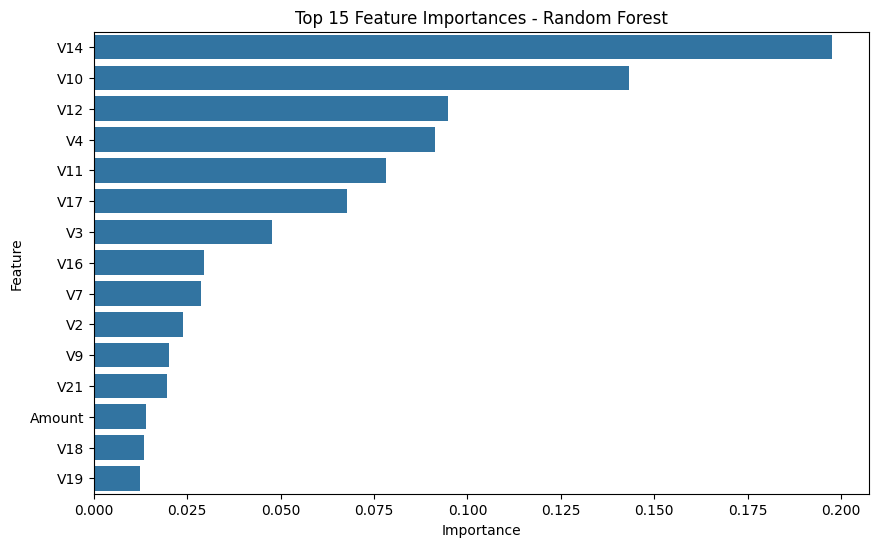

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Random Forest feature importance identified V14, V10, V12, V4 and V11 among the most influential features. These features are anonymized PCA-derived variables, so their importance should not be interpreted as causal relationships.

#9. XGBoost

In [41]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [42]:
from xgboost import XGBClassifier

# Calculate the imbalance ratio
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 577.2868020304569


In [43]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [44]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [45]:
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.56      0.86      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.93      0.84     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56798    66]
 [   14    84]]
ROC-AUC: 0.977014437598337
PR-AUC: 0.8493951913279806


In [46]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Precision:", precision[best_index])
print("Recall:", recall[best_index])
print("F1-score:", f1_scores[best_index])

Best threshold: 0.97667533
Precision: 0.8666666666666667
Recall: 0.7959183673469388
F1-score: 0.8297872339926438


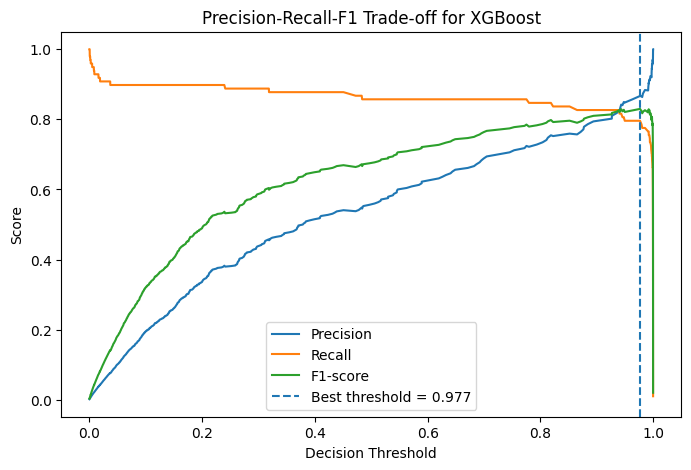

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-score')

plt.axvline(
    best_threshold,
    linestyle='--',
    label=f'Best threshold = {best_threshold:.3f}'
)

plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall-F1 Trade-off for XGBoost')
plt.legend()

plt.show()

In [48]:
best_threshold = 0.97667533

y_pred_xgb_tuned = (
    y_prob_xgb >= best_threshold
).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56852    12]
 [   20    78]]


In [49]:
cm = confusion_matrix(y_test, y_pred_xgb_tuned)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 56852
False Positives: 12
False Negatives: 20
True Positives  : 78


In [50]:
from sklearn.model_selection import train_test_split

X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Inner training set:", X_train_inner.shape)
print("Validation set:", X_val.shape)

print("Training fraud %:", y_train_inner.mean() * 100)
print("Validation fraud %:", y_val.mean() * 100)

Inner training set: (182276, 31)
Validation set: (45569, 31)
Training fraud %: 0.17281485220215498
Validation fraud %: 0.1733634707805745


In [51]:
scale_pos_weight_inner = (
    y_train_inner.value_counts()[0] /
    y_train_inner.value_counts()[1]
)

print("Scale Pos Weight:", scale_pos_weight_inner)

Scale Pos Weight: 577.6539682539683


In [52]:
xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_inner,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(X_train_inner, y_train_inner)

print("Fresh XGBoost model trained successfully!")

Fresh XGBoost model trained successfully!


In [53]:
y_val_prob = xgb_final.predict_proba(X_val)[:, 1]

print("Validation probabilities generated!")

Validation probabilities generated!


In [54]:
precision_val, recall_val, thresholds_val = precision_recall_curve(
    y_val,
    y_val_prob
)

f1_val = (
    2 * precision_val * recall_val /
    (precision_val + recall_val + 1e-10)
)

best_index_val = f1_val.argmax()

best_threshold_val = thresholds_val[best_index_val]

print("Best validation threshold:", best_threshold_val)
print("Validation Precision:", precision_val[best_index_val])
print("Validation Recall:", recall_val[best_index_val])
print("Validation F1:", f1_val[best_index_val])

Best validation threshold: 0.987879
Validation Precision: 0.9375
Validation Recall: 0.759493670886076
Validation F1: 0.8391608391113893


The XGBoost decision threshold was selected using the validation set rather than the test set. The selected threshold was then locked and applied once to the untouched test set.

In [55]:
# Generate fraud probabilities on the untouched test set
y_test_prob_final = xgb_final.predict_proba(X_test)[:, 1]

# Apply the locked validation threshold
y_test_pred_final = (
    y_test_prob_final >= best_threshold_val
).astype(int)

print("Final test predictions generated!")

Final test predictions generated!


In [56]:
print("FINAL XGBoost Classification Report:")
print(classification_report(y_test, y_test_pred_final))

print("FINAL Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

print("FINAL ROC-AUC:",
      roc_auc_score(y_test, y_test_prob_final))

print("FINAL PR-AUC:",
      average_precision_score(y_test, y_test_prob_final))

FINAL XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.76      0.81        98

    accuracy                           1.00     56962
   macro avg       0.94      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962

FINAL Confusion Matrix:
[[56854    10]
 [   24    74]]
FINAL ROC-AUC: 0.9785645019121886
FINAL PR-AUC: 0.8574083869396152


#SHAP Explainability

In [57]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [58]:
import shap

explainer = shap.TreeExplainer(xgb_final)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [59]:
X_shap = X_val.sample(
    n=2000,
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 31)


In [60]:
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (2000, 31)


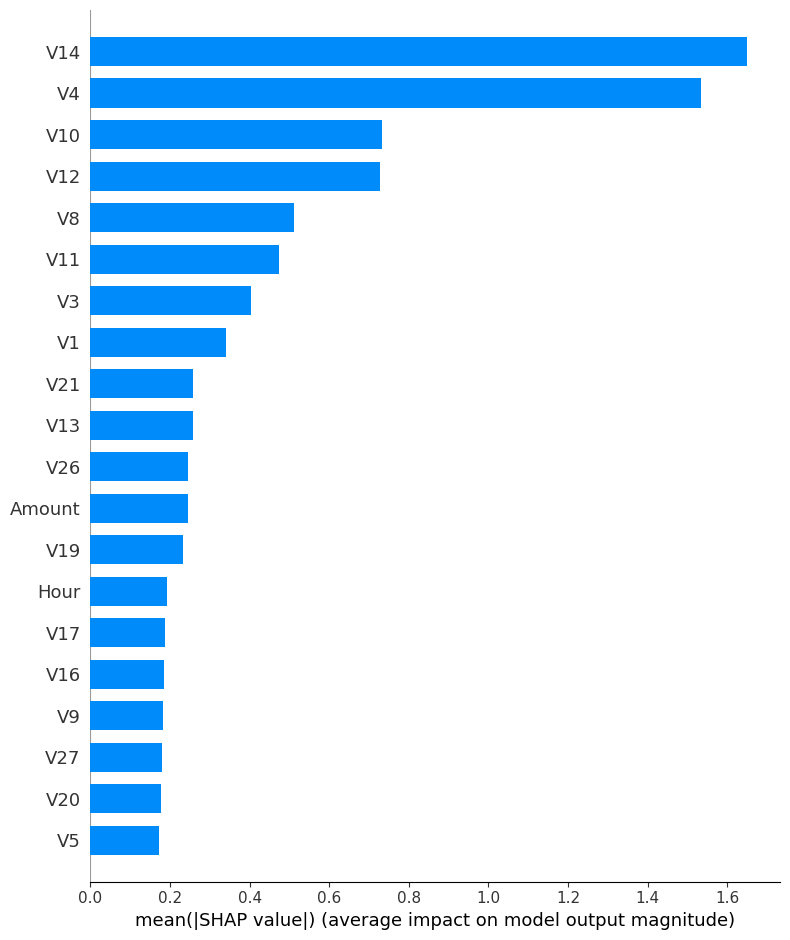

In [61]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

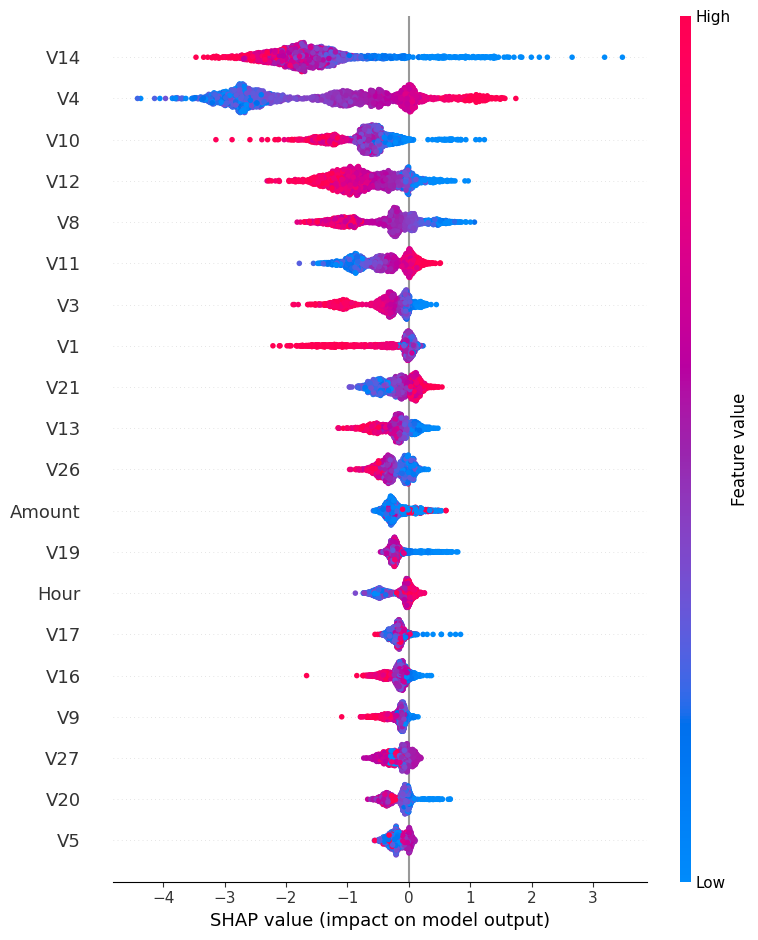

In [62]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

## SHAP Explainability

SHAP analysis was used to investigate the contribution of individual features to the XGBoost model's predictions.

The global SHAP analysis identified V14, V4, V10, V12, V8 and V11 among the most influential features.

Because V1–V28 are anonymized PCA-derived features, these results indicate predictive contribution rather than causal relationships or directly interpretable banking attributes.

In [63]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'SMOTE + Logistic Regression',
        'Random Forest',
        'XGBoost (Tuned Threshold)'
    ],
    'Precision': [
        0.829,
        0.056,
        0.055,
        0.960,
        0.880
    ],
    'Recall': [
        0.643,
        0.908,
        0.918,
        0.724,
        0.755
    ],
    'F1 Score': [
        0.724,
        0.100,
        0.100,
        0.830,
        0.810
    ],
    'ROC-AUC': [
        0.9621,
        0.9736,
        0.9730,
        0.9530,
        0.9786
    ],
    'PR-AUC': [
        0.7419,
        0.7222,
        0.7307,
        0.8616,
        0.8574
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.829,0.643,0.724,0.9621,0.7419
1,Balanced Logistic Regression,0.056,0.908,0.100,0.9736,0.7222
2,SMOTE + Logistic Regression,0.055,0.918,0.100,0.9730,0.7307
3,Random Forest,0.960,0.724,0.830,0.9530,0.8616
4,XGBoost (Tuned Threshold),0.880,0.755,0.810,0.9786,0.8574


<Figure size 1200x600 with 0 Axes>

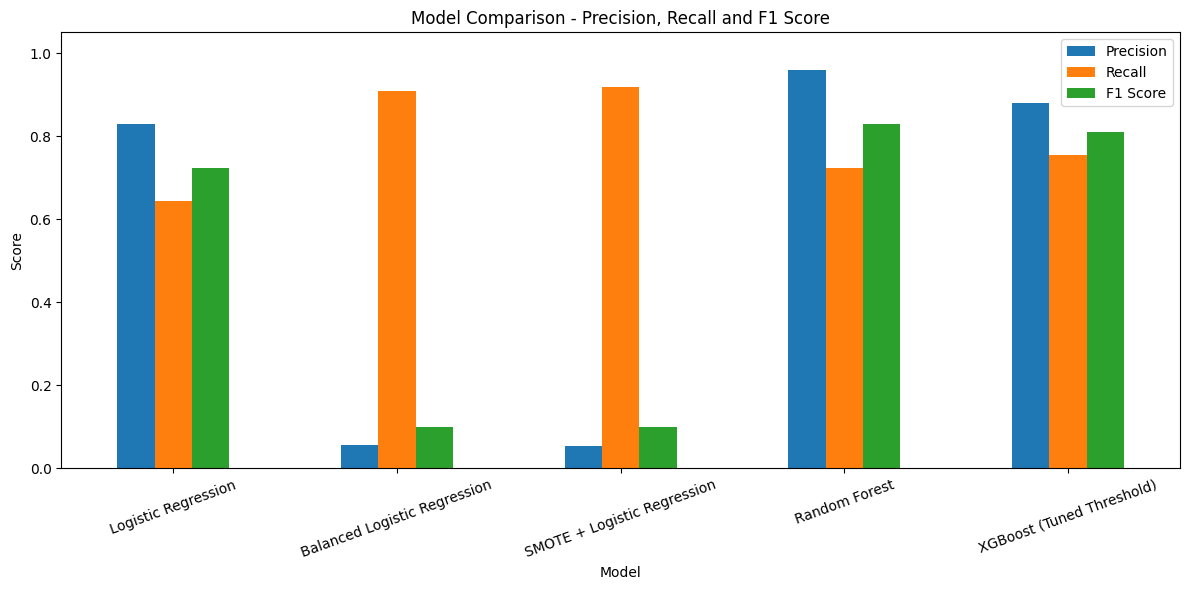

In [64]:
plt.figure(figsize=(12, 6))

results_plot = results.set_index('Model')

results_plot[['Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Comparison - Precision, Recall and F1 Score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.show()

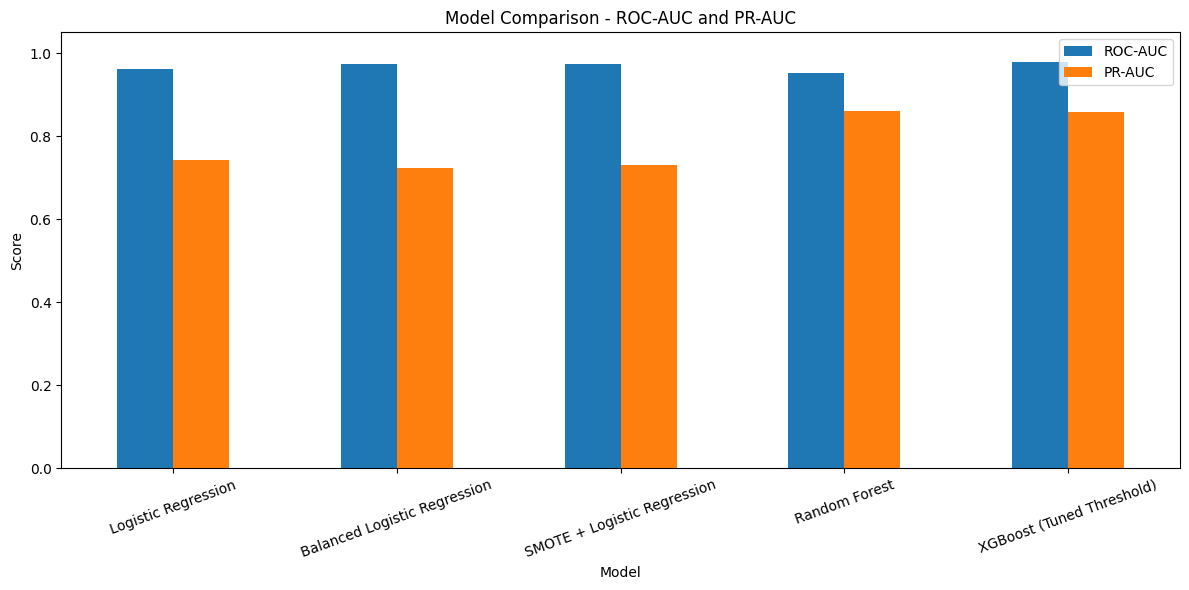

In [65]:
results_plot[['ROC-AUC', 'PR-AUC']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Comparison - ROC-AUC and PR-AUC')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.show()

In [66]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_inner, y_train_inner)

print("Fresh Random Forest trained successfully!")

Fresh Random Forest trained successfully!


In [67]:
y_val_prob_rf = rf_final.predict_proba(X_val)[:, 1]

#10. Threshold Optimization

In [68]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_val,
    y_val_prob_rf
)

f1_rf = (
    2 * precision_rf * recall_rf /
    (precision_rf + recall_rf + 1e-10)
)

best_index_rf = f1_rf.argmax()

best_threshold_rf = thresholds_rf[best_index_rf]

print("Best RF validation threshold:", best_threshold_rf)
print("Validation Precision:", precision_rf[best_index_rf])
print("Validation Recall:", recall_rf[best_index_rf])
print("Validation F1:", f1_rf[best_index_rf])

Best RF validation threshold: 0.26
Validation Precision: 0.8985507246376812
Validation Recall: 0.7848101265822784
Validation F1: 0.8378378377880661


Random Forest threshold = 0.26

XGBoost threshold       = 0.987879

In [69]:
# Generate probabilities on the untouched test set
y_test_prob_rf = rf_final.predict_proba(X_test)[:, 1]

# Apply the locked validation threshold
y_test_pred_rf = (
    y_test_prob_rf >= best_threshold_rf
).astype(int)

print("Final Random Forest predictions generated!")

Final Random Forest predictions generated!


In [70]:
print("FINAL Random Forest Classification Report:")
print(classification_report(y_test, y_test_pred_rf))

print("FINAL Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

print("FINAL Random Forest ROC-AUC:",
      roc_auc_score(y_test, y_test_prob_rf))

print("FINAL Random Forest PR-AUC:",
      average_precision_score(y_test, y_test_prob_rf))

FINAL Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

FINAL Random Forest Confusion Matrix:
[[56852    12]
 [   16    82]]
FINAL Random Forest ROC-AUC: 0.9579755456628346
FINAL Random Forest PR-AUC: 0.8583006134061641


In [71]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("True Negatives :", tn_rf)
print("False Positives:", fp_rf)
print("False Negatives:", fn_rf)
print("True Positives :", tp_rf)

True Negatives : 56852
False Positives: 12
False Negatives: 16
True Positives : 82


#11. Final Model Comparison ⭐

| Model | Precision | Recall | F1 Score | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| **Random Forest** | **87.2%** | **83.7%** | **85.2%** | 95.80% | **85.83%** |
| XGBoost | 88.0% | 75.5% | 81.0% | **97.86%** | 85.74% |

# 12. Final Random Forest Evaluation

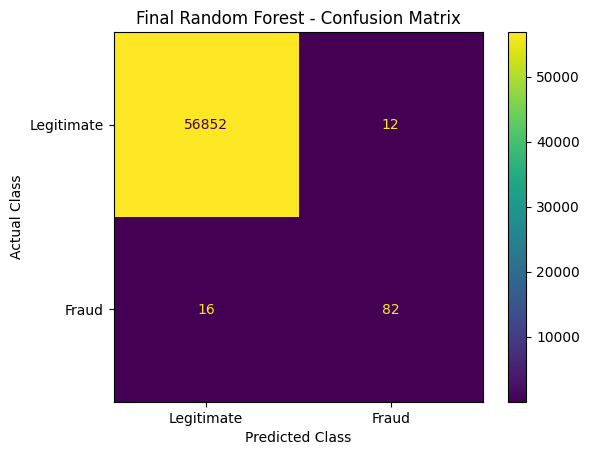

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_rf,
    display_labels=['Legitimate', 'Fraud']
)

plt.title('Final Random Forest - Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

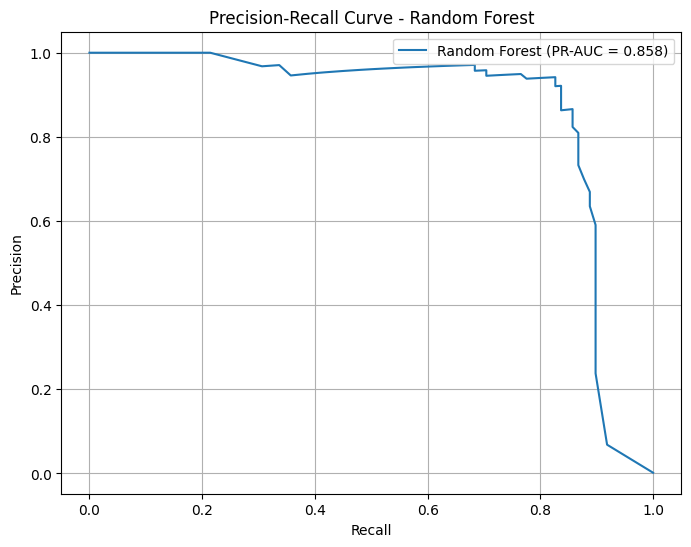

In [73]:
from sklearn.metrics import precision_recall_curve

precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(
    y_test,
    y_test_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_rf_curve,
    precision_rf_curve,
    label=f'Random Forest (PR-AUC = {average_precision_score(y_test, y_test_prob_rf):.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.show()

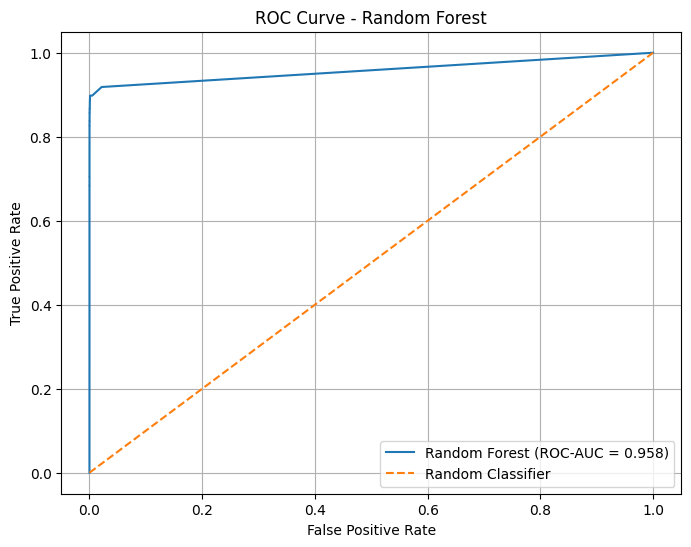

In [74]:
from sklearn.metrics import roc_curve, auc

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_test_prob_rf
)

roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (ROC-AUC = {roc_auc_rf:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.show()

In [75]:
final_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost'
    ],
    'Precision': [
        0.872,
        0.880
    ],
    'Recall': [
        0.837,
        0.755
    ],
    'F1 Score': [
        0.852,
        0.810
    ],
    'ROC-AUC': [
        0.9580,
        0.9786
    ],
    'PR-AUC': [
        0.8583,
        0.8574
    ]
})

final_results

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest,0.872,0.837,0.852,0.9580,0.8583
1,XGBoost,0.880,0.755,0.810,0.9786,0.8574


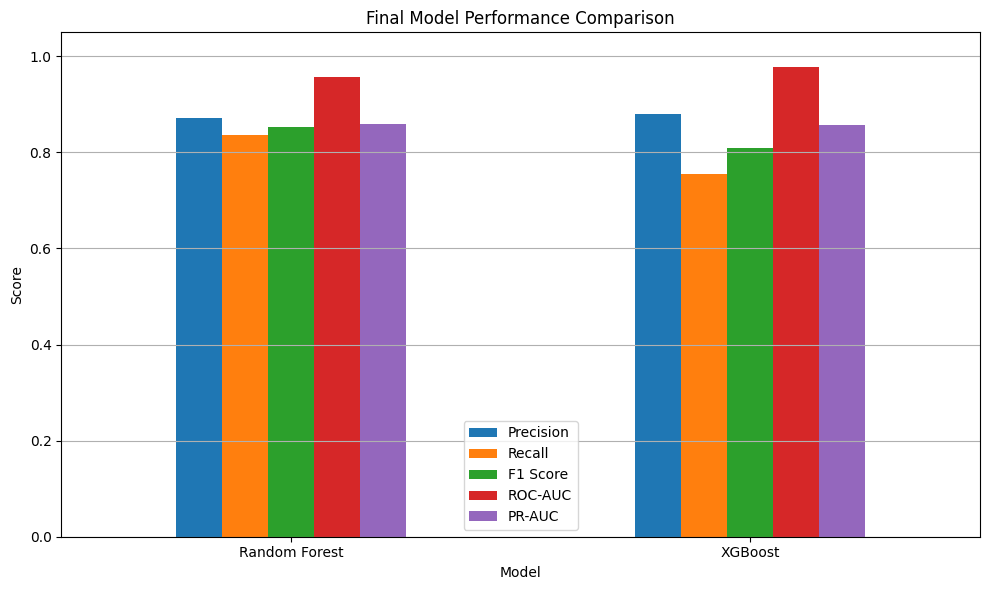

In [76]:
final_results.set_index('Model')[
    ['Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Final Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Final Conclusion


# Conclusion

This project developed and evaluated machine learning models for credit card fraud detection under severe class imbalance.

Logistic Regression was established as the baseline model. Class weighting and SMOTE substantially increased fraud recall but resulted in a large increase in false positives.

Random Forest and XGBoost provided substantially stronger precision-recall performance. After validation-based threshold optimization, Random Forest achieved the strongest overall balance, with 87.2% fraud precision, 83.7% fraud recall, an F1-score of 85.2%, and PR-AUC of 0.8583 on the untouched test set.

XGBoost achieved a higher ROC-AUC of 0.9786 and slightly higher precision, but its recall and F1-score were lower than those of Random Forest.

Therefore, Random Forest was selected as the preferred model for the current implementation.

## Future Work

Potential extensions include:

- Hyperparameter tuning using systematic cross-validation
- Cost-sensitive threshold optimization based on real-world fraud and false-alarm costs
- Further model calibration
- More advanced explainability analysis
- Evaluation on additional or more recent transaction datasets
- Deployment as a real-time fraud detection API
- Monitoring model performance and concept drift after deployment

In [82]:
import os

print(os.listdir('/content'))

['.config', 'archive.zip', 'creditcard.csv', 'sample_data']
